In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wspr_folium_map import create_spot_map
from wspr_analysis_utils import (
    load_data,
    discover_bands_from_dataset,
    assign_band_column,
    prepare_dataframe,
    BAND_RANGES,
)

sns.set(context='talk', style='whitegrid', palette='tab10', rc={'figure.dpi': 120})


In [2]:
# ── User configuration (edit these) ────────────────────────────────────────
TSV_FILENAME      = '40m_loaded_dipole_30ft_mast_spots.tsv'   # local TSV path, or None
CALLSIGN          = 'KD3CCO'                 # station call sign to analyze
START_UTC         = None                     # e.g. '2026-06-01T00:00:00' or None
END_UTC           = None                     # e.g. '2026-06-07T23:59:59' or None
DOWNLOAD_FROM_API = False                    # True → download from wspr.rocks
# ────────────────────────────────────────────────────────────────────────────

df = load_data(
    tsv_path=TSV_FILENAME,
    call_sign=CALLSIGN,
    start_utc=START_UTC,
    end_utc=END_UTC,
    download=DOWNLOAD_FROM_API,
)

BANDS = discover_bands_from_dataset(df)
if not BANDS:
    BANDS = list(BAND_RANGES.keys())

print('Dataset rows:', len(df))
print('Bands present:', BANDS)
print(f'{CALLSIGN} as TX:', (df['TX'] == CALLSIGN).sum())
print(f'{CALLSIGN} as RX:', (df['RX'] == CALLSIGN).sum())


Dataset rows: 826
Bands present: ['40m']
KD3CCO as TX: 686
KD3CCO as RX: 140


## Analysis 1: Band Openings and Closures

This analysis tracks spot counts and mean SNR across time bins for each band.

Purpose:
- Show when individual amateur bands are most active, and whether propagation is strengthening or weakening over time.
- Highlight changes in the Maximum Usable Frequency (MUF) by comparing multiple bands in the same time window.

How to interpret:
- A rising spot count means the band is opening and more stations are being heard.
- An increasing mean SNR indicates better signal strength and propagation quality.
- Bands that drop sharply suggest closures or fading conditions.

Possible conclusions:
- Identify the best operating times for each band.
- Determine whether the dataset captures a transition from lower-frequency to higher-frequency propagation.
- Spot any bands that remain weak despite others opening, which may suggest local antenna tuning or band-specific absorption.


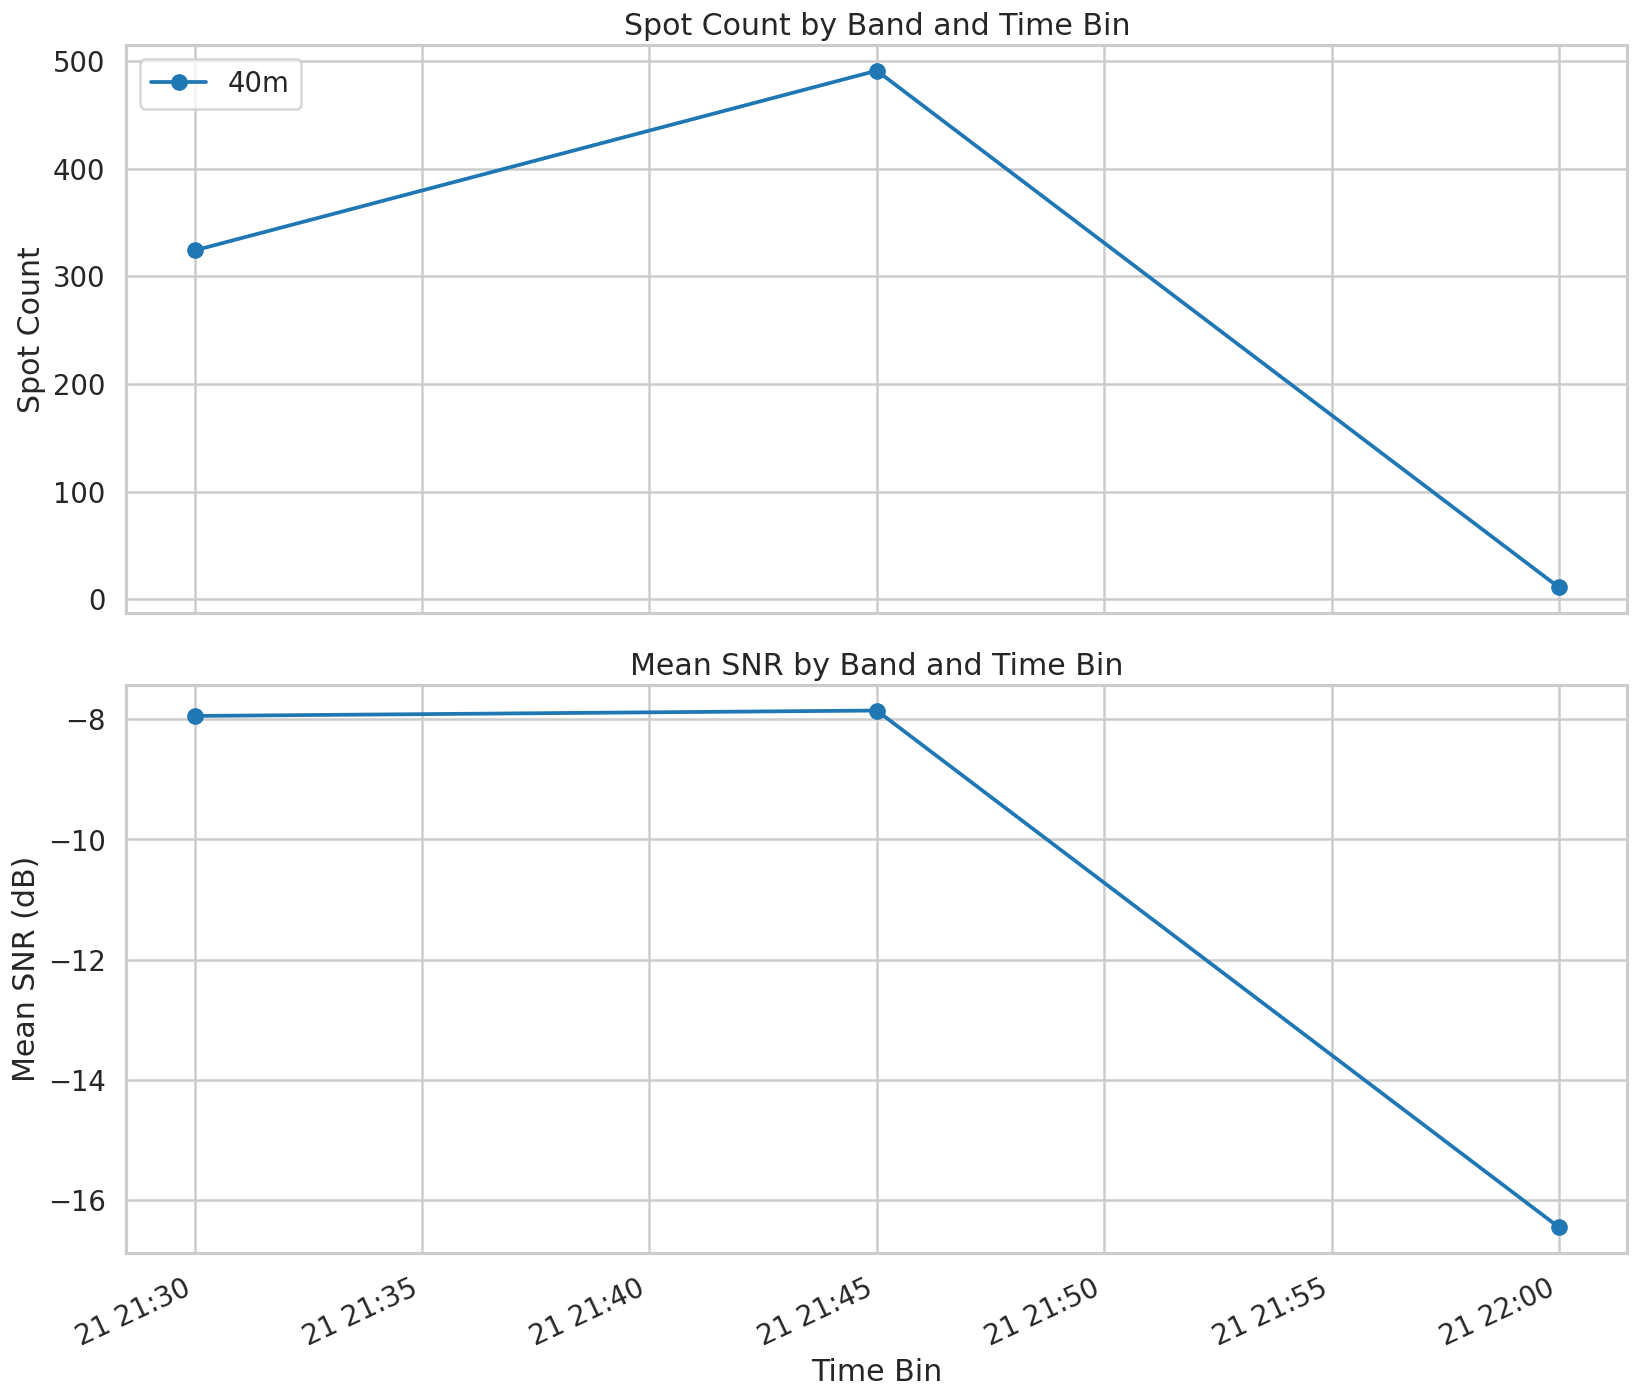

In [3]:
rate = df.groupby(['TimeBin', 'Band']).agg(spot_count=('Time', 'count'), mean_snr=('SNR', 'mean')).reset_index()
rate = rate[rate['Band'] != 'Other']

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
band_order = [b for b in list(BAND_RANGES.keys()) if b in rate['Band'].unique()]
for band in band_order:
    band_data = rate[rate['Band'] == band]
    axes[0].plot(band_data['TimeBin'], band_data['spot_count'], label=band, marker='o')
    axes[1].plot(band_data['TimeBin'], band_data['mean_snr'], label=band, marker='o')

axes[0].set_ylabel('Spot Count')
axes[0].set_title('Spot Count by Band and Time Bin')
axes[0].legend(loc='upper left', ncol=4)
axes[1].set_ylabel('Mean SNR (dB)')
axes[1].set_title('Mean SNR by Band and Time Bin')
axes[1].set_xlabel('Time Bin')
fig.autofmt_xdate(rotation=25)
fig.tight_layout()
plt.show()


## Analysis 2: Distance Profiling

This analysis computes mean, maximum, and standard deviation of path distance `k` for every band.

Purpose:
- Quantify how far your station is reaching on each band in the dataset.
- Use the band-specific statistics to compare the effective propagation range across frequencies.

How to interpret:
- Mean distance is the typical path length heard on each band.
- Maximum distance shows the furthest recorded reach and can indicate DX potential.
- Standard deviation reveals how variable the propagation is during the session.

Possible conclusions:
- Bands with higher mean distance are favoring longer skip paths.
- A low standard deviation on a band suggests stable propagation, while a high value indicates mixed local and DX contacts.
- If a high-frequency band has a very small mean distance, the band may be only marginally open.


In [4]:
distance_stats = df[df['Band'] != 'Other'].groupby('Band')['k'].agg(['mean', 'max', 'std', 'count']).reset_index()
order = [b for b in list(BAND_RANGES.keys()) if b in distance_stats['Band'].unique()]
distance_stats['Band'] = pd.Categorical(distance_stats['Band'], categories=order, ordered=True)
distance_stats = distance_stats.sort_values('Band')
distance_stats


,Band,mean,max,std,count
0,40m,1802.946731,18429,2407.692259,826


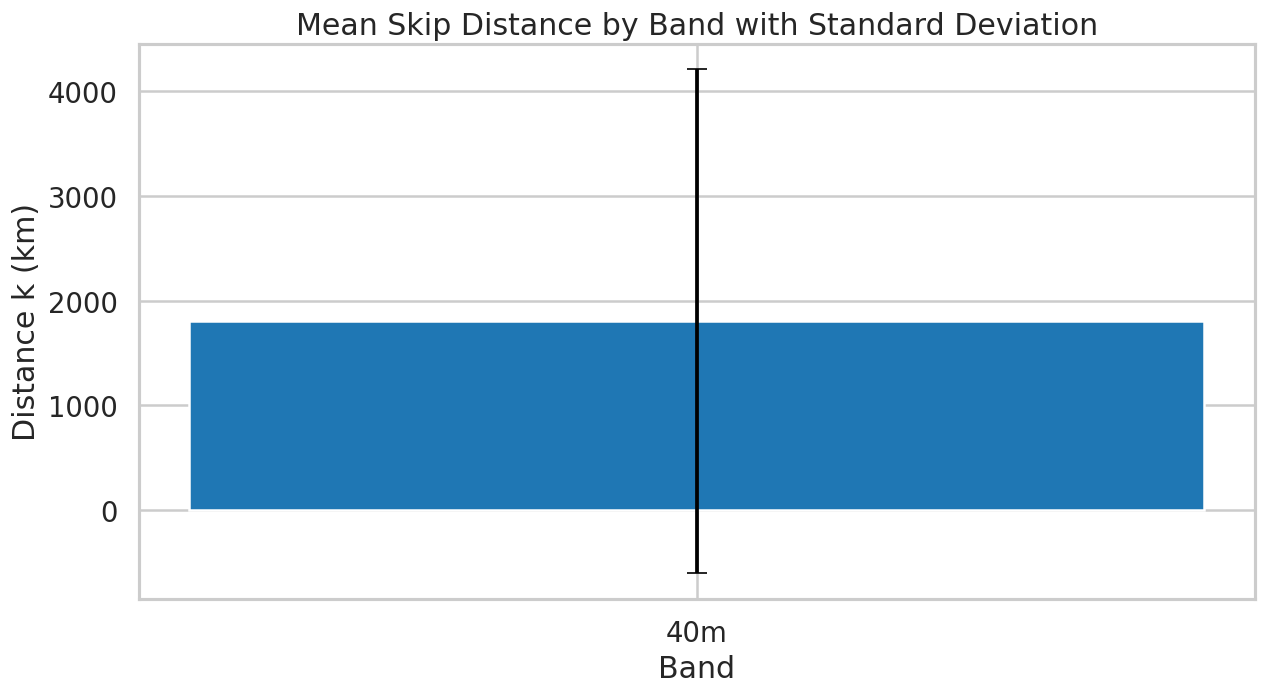

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(distance_stats['Band'], distance_stats['mean'], yerr=distance_stats['std'], capsize=6, color=sns.color_palette('tab10', len(distance_stats)))
ax.set_title('Mean Skip Distance by Band with Standard Deviation')
ax.set_xlabel('Band')
ax.set_ylabel('Distance k (km)')
plt.show()


## Analysis 3: Geographical Spread

This analysis identifies the strongest footprint by the top receive grid prefixes.

Purpose:
- Visualize the geographic distribution of contacts by memory of the most active Maidenhead grid areas.
- Understand whether your station is mainly heard domestically, regionally, or in long-distance DX regions.

How to interpret:
- The top grid prefixes show the regions that contribute the largest number of spots.
- A dense domestic footprint suggests strong local and regional propagation.
- Presence of distant grid squares indicates longer skip or transoceanic paths.

Possible conclusions:
- Assess whether the dataset captures mostly local propagation or meaningful DX reach.
- Identify key target regions that the antenna and current conditions favor.
- Use this information to compare with azimuthal coverage and band-specific reach.


In [6]:
top_grids = df[df['TX'] == CALLSIGN]['rxPrefix'].value_counts().head(20).reset_index()
top_grids.columns = ['Grid', 'Count']
top_grids

,Grid,Count
0,FM18,45
1,FN30,35
2,EN82,32
3,FM05,28
4,DN70,21
5,FN21,19
6,FN31,16
7,FM08,16
8,FN20,16
9,FN42,16


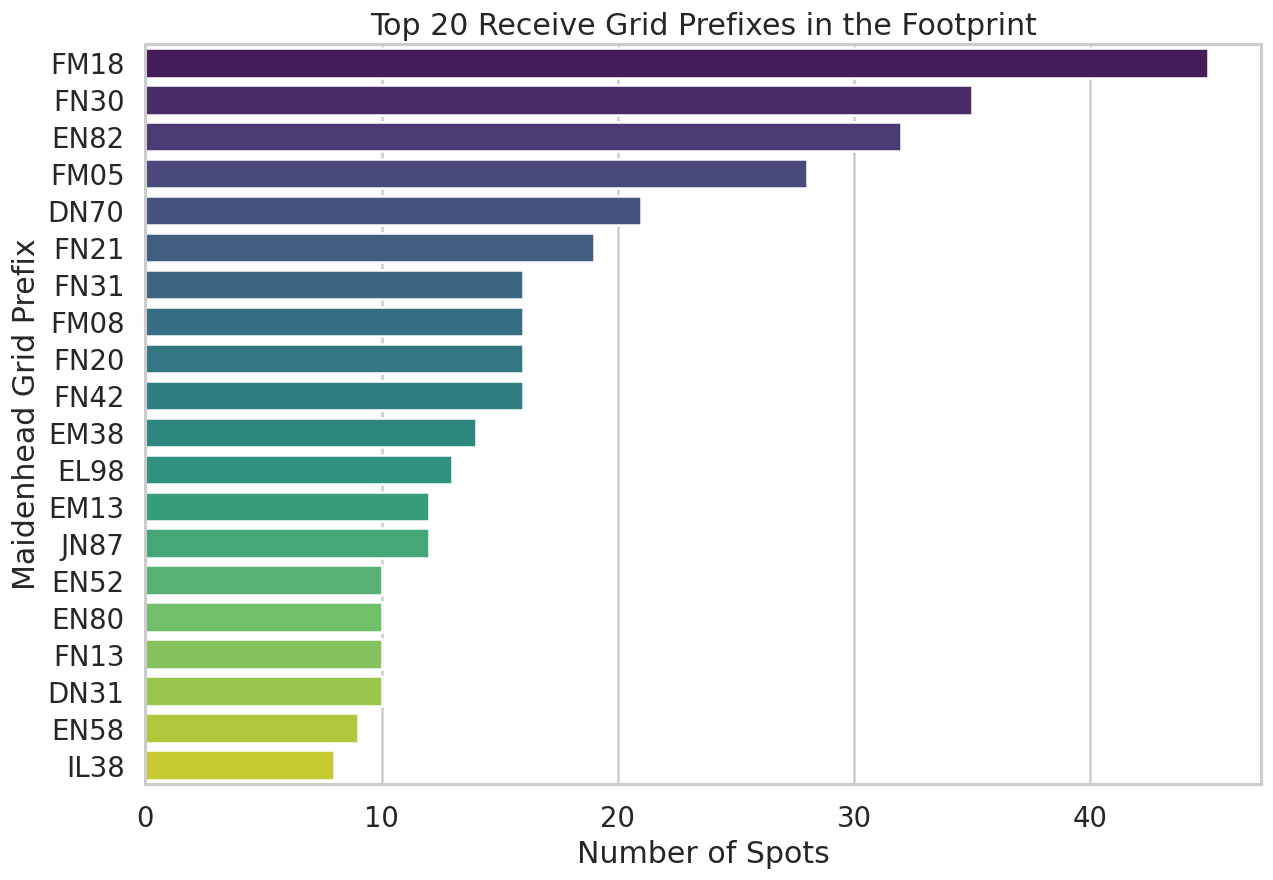

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_grids, x='Count', y='Grid', hue='Grid', palette='viridis', legend=False, ax=ax)
ax.set_title('Top 20 Receive Grid Prefixes in the Footprint')
ax.set_xlabel('Number of Spots')
ax.set_ylabel('Maidenhead Grid Prefix')
plt.show()

## Analysis 4: SNR vs Distance Regression

This analysis examines path loss trends by plotting SNR against distance for each band.

Purpose:
- Measure how signal strength declines with distance on each band.
- Compare the relative attenuation characteristics across bands.

How to interpret:
- A downward trend is expected: longer distances usually produce lower SNR.
- A tight regression line indicates consistent path loss behavior.
- Scatter far above the trend suggests strong openings or unusually favorable propagation.

Possible conclusions:
- Determine whether some bands are behaving more predictably than others.
- Detect bands where antenna performance or local noise may be affecting SNR independently of distance.
- Spot deviations that could indicate special propagation modes or anomalous paths.


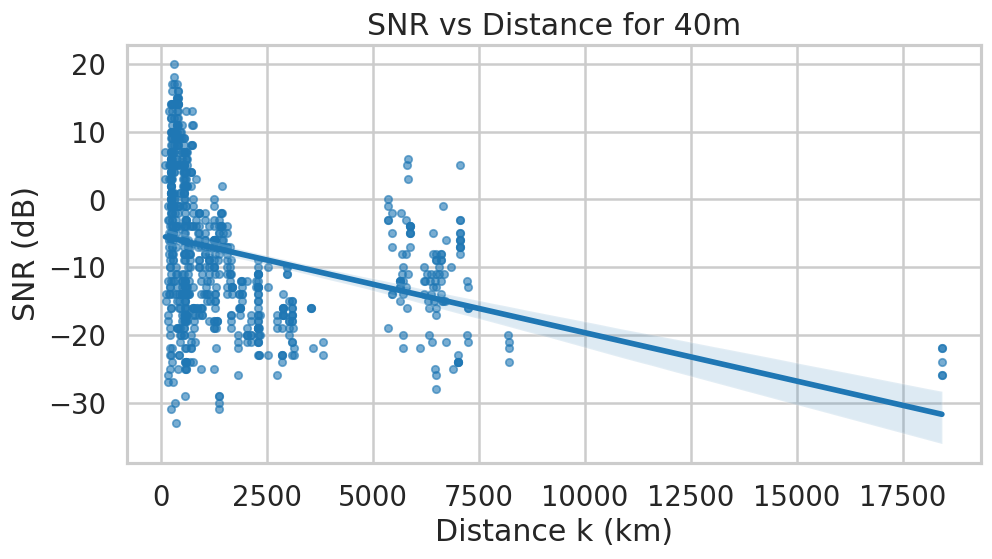

In [8]:
import math

bands_in_plot = [b for b in BANDS if b in df['Band'].unique()]
ncols = 2
nrows = math.ceil(len(bands_in_plot) / ncols) if bands_in_plot else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5), sharex=False, sharey=False)
axes = axes.flatten()

plot_data = df[df['Band'].isin(bands_in_plot)]
for i, band in enumerate(bands_in_plot):
    band_data = plot_data[plot_data['Band'] == band]
    if len(band_data) > 0:
        sample = band_data.sample(n=min(len(band_data), 800), random_state=1)
        sns.regplot(data=sample, x='k', y='SNR', scatter_kws={'s': 20, 'alpha': 0.6}, ax=axes[i])
    axes[i].set_title(f'SNR vs Distance for {band}')
    axes[i].set_xlabel('Distance k (km)')
    axes[i].set_ylabel('SNR (dB)')

for j in range(len(bands_in_plot), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

## Analysis 5: TX vs RX Asymmetry (Local Noise Floor Test)

This comparison uses reciprocal paths involving the configured station as both transmitter and receiver.

Purpose:
- Compare how your transmit and receive paths perform for the same remote station and band.
- Reveal whether one direction is consistently stronger, which can indicate local noise, feedline loss, or antenna imbalance.

How to interpret:
- The histogram of `SNR_delta` shows whether TX or RX is generally stronger.
- Values above zero mean TX reports stronger signals than RX.
- Values below zero mean RX reports stronger signals than TX.

Possible conclusions:
- A positive skew suggests the receive path may be suffering from higher local noise or lower sensitivity.
- A negative skew suggests the transmit path may have more loss or less effective radiation.
- A distribution centered near zero indicates roughly symmetric link performance in both directions.

In [9]:
if 'Band' not in df.columns:
    df = assign_band_column(df)

if 'az_rad' not in df.columns and 'az' in df.columns:
    df['az_rad'] = np.radians(df['az'].astype(float))

tx = df[df['TX'] == CALLSIGN][['Time', 'Band', 'RX', 'SNR', 'k', 'az']].rename(columns={'RX': 'Remote', 'SNR': 'SNR_tx', 'Time': 'Time_tx', 'k': 'k_tx', 'az': 'az_tx'})
rx = df[df['RX'] == CALLSIGN][['Time', 'Band', 'TX', 'SNR', 'k', 'az']].rename(columns={'TX': 'Remote', 'SNR': 'SNR_rx', 'Time': 'Time_rx', 'k': 'k_rx', 'az': 'az_rx'})

paired = pd.merge(rx, tx, on=['Remote', 'Band'], suffixes=('_rx', '_tx'))
paired['time_delta'] = (paired['Time_tx'] - paired['Time_rx']).abs()
paired = paired[paired['time_delta'] <= pd.Timedelta('20min')].copy()
paired = paired.sort_values(['Remote', 'Band', 'Time_rx', 'time_delta']).drop_duplicates(['Remote', 'Band', 'Time_rx'])
paired['SNR_delta'] = paired['SNR_tx'] - paired['SNR_rx']
paired['abs_time_delta_min'] = paired['time_delta'] / pd.Timedelta('1min')
paired[['Remote', 'Band', 'SNR_tx', 'SNR_rx', 'SNR_delta', 'abs_time_delta_min']].head()


,Remote,Band,SNR_tx,SNR_rx,SNR_delta,abs_time_delta_min
26,DK2DB,40m,-8,-17,9,14.0
5,DK2DB,40m,-8,-16,8,2.0
37,KA3SKN,40m,-20,-13,-7,4.0
15,KA3SKN,40m,-25,-9,-16,2.0
0,KB3EDF,40m,4,-12,16,2.0


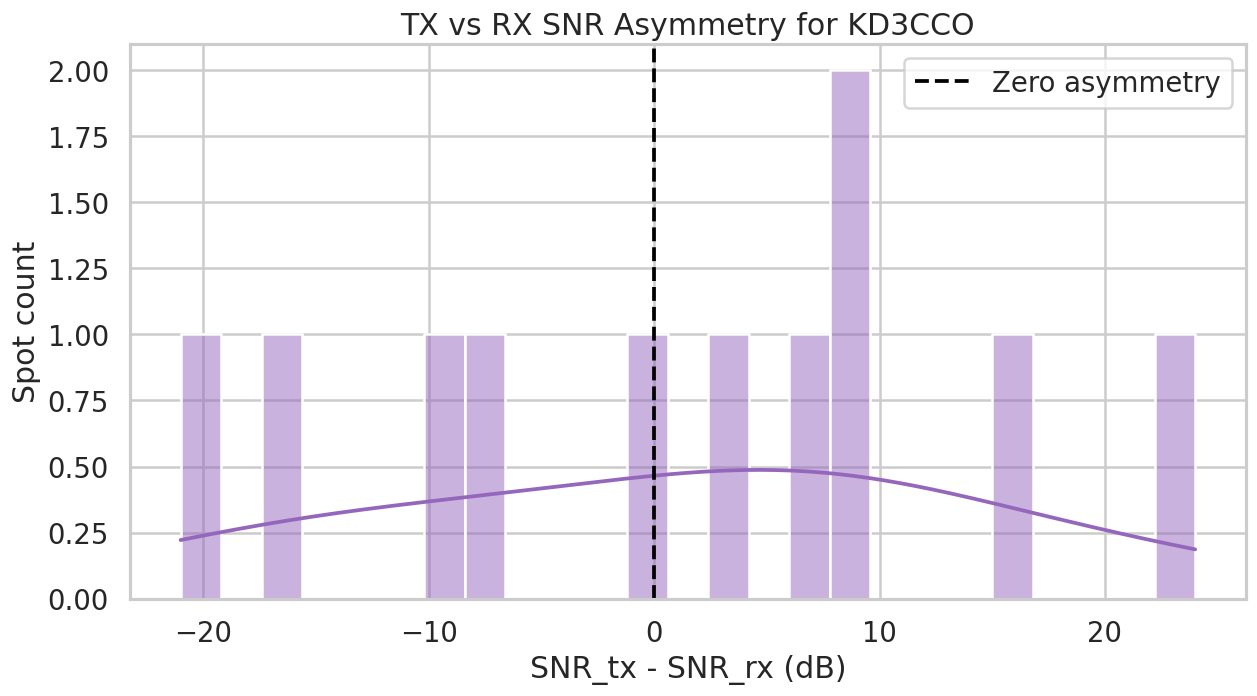

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(paired['SNR_delta'], bins=25, kde=True, color='tab:purple', ax=ax)
ax.axvline(0, color='black', linestyle='--', label='Zero asymmetry')
ax.set_title(f'TX vs RX SNR Asymmetry for {CALLSIGN}')
ax.set_xlabel('SNR_tx - SNR_rx (dB)')
ax.set_ylabel('Spot count')
ax.legend()
plt.show()

## Analysis 6: Azimuthal Pattern Mapping

This polar map shows spot direction and distance for the configured station's transmissions.

Purpose:
- Map how signal strength and path length vary with bearing from the station.
- Identify favored antenna lobes and weak nulls in the horizontal plane.

How to interpret:
- Angle corresponds to compass bearing.
- Radius corresponds to path distance.
- Color corresponds to received SNR, so brighter points show stronger paths.

Possible conclusions:
- Strong clusters in certain directions may reveal directional gain or propagation favoring those headings.
- Low-density sectors may indicate nulls or blocked bearings.
- Comparing distance and color helps separate directional propagation from antenna pattern effects.


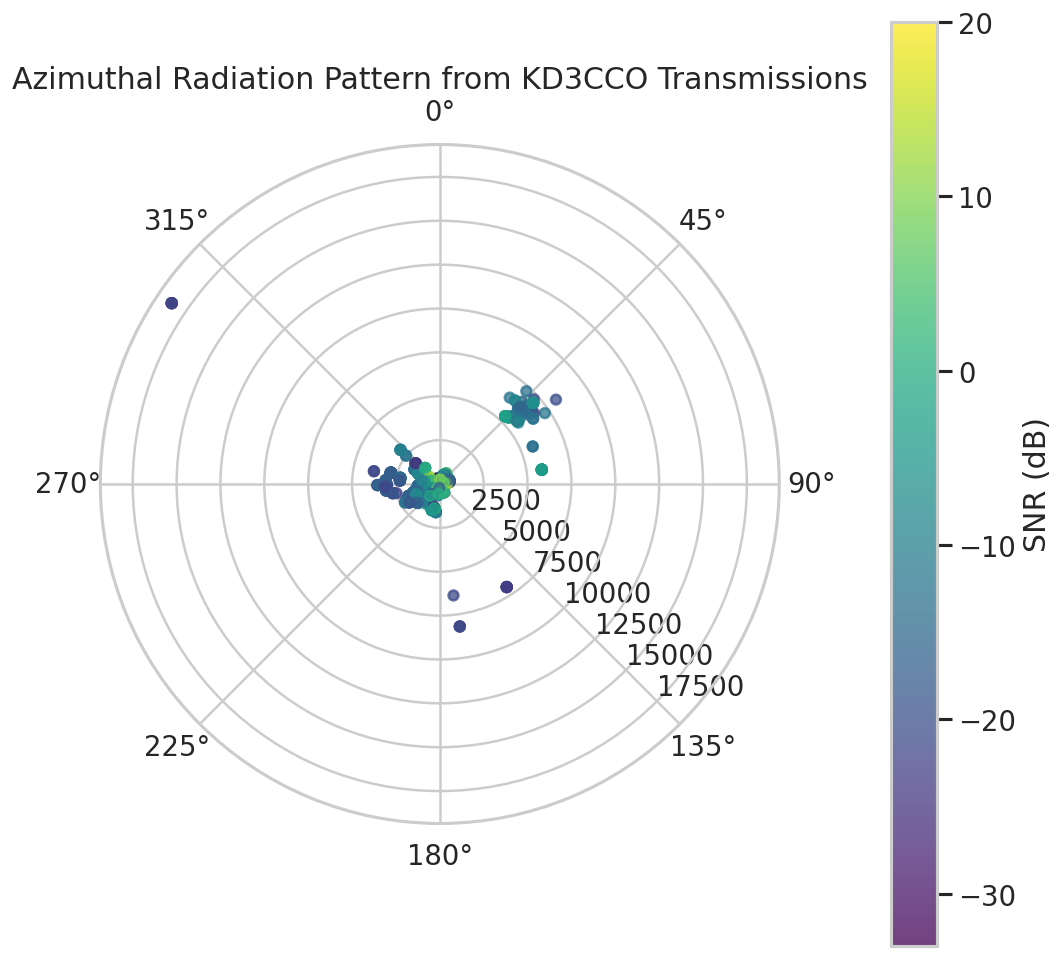

In [11]:
tx_local = df[df['TX'] == CALLSIGN]
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')
sc = ax.scatter(tx_local['az_rad'], tx_local['k'], c=tx_local['SNR'], cmap='viridis', s=35, alpha=0.75)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title(f'Azimuthal Radiation Pattern from {CALLSIGN} Transmissions')
cbar = fig.colorbar(sc, ax=ax, pad=0.12)
cbar.set_label('SNR (dB)')
ax.set_rlabel_position(135)
plt.show()


## Analysis 7: Band-by-Band Efficiency Normalization

This analysis compares `k/W` across bands for stations that heard the configured station on 3 or more bands.

Purpose:
- Normalize path reach by transmitted power to compare relative efficiency across frequencies.
- Focus on multi-band reference stations to reduce bias from one-off contacts.

How to interpret:
- Higher `k/W` means the station received farther distance for the same power.
- Lower values on a specific band can indicate matching loss, antenna inefficiency, or poor propagation.

Possible conclusions:
- If higher bands show significantly lower `k/W`, the antenna system may be losing efficiency on harmonics.
- Consistent values across bands suggest the matching network and antenna are performing evenly.
- Outliers may point to particular remote stations or directional effects rather than general antenna behavior.


In [12]:
if len(BANDS) < 3:
    print(f'Only {len(BANDS)} band(s) present; skipping the band efficiency '
          'normalization comparison, since it requires remote stations heard '
          'on 3 or more bands.')
else:
    multi_band = df[df['TX'] == CALLSIGN].groupby('RX')['Band'].nunique()
    multi_band = multi_band[multi_band >= 3].index
    efficiency = df[(df['TX'] == CALLSIGN) & (df['RX'].isin(multi_band))].copy()
    efficiency = efficiency[efficiency['Band'] != 'Other']
    efficiency['k_per_watt'] = efficiency['k'] / efficiency['Watts']
    fig, ax = plt.subplots(figsize=(14, 8))
    order = [b for b in list(BAND_RANGES.keys()) if b in efficiency['Band'].unique()]
    sns.boxplot(data=efficiency, x='Band', y='k_per_watt', order=order, ax=ax)
    ax.set_title('Normalized Path Efficiency (k/W) by Band for Multi-band Remote Stations')
    ax.set_ylabel('Distance per Watt (k/W)')
    ax.set_xlabel('Band')
    plt.show()

Only 1 band(s) present; skipping the band efficiency normalization comparison, since it requires remote stations heard on 3 or more bands.


## Analysis 8: Take-Off Angle Inference via Minimum Skip Boundaries

This analysis examines the shortest paths on the higher bands, which informs the likely takeoff angle and near-skip zone.

Purpose:
- Use the lower end of the distance distribution to infer whether the antenna favors low-angle, DX-style radiation or higher-angle local propagation.

How to interpret:
- Shorter 10th and 25th percentile distances imply that the band includes nearer, low-angle paths.
- Larger values suggest the first usable skip is farther away, which may correspond to a higher takeoff angle.

Possible conclusions:
- A small minimum skip boundary is consistent with a low takeoff angle and good near-field performance.
- A large boundary can indicate a high takeoff angle or that the station is primarily hearing longer-range paths.
- Comparing these percentiles across bands helps reveal whether the antenna pattern changes with frequency.


In [13]:
ALL_HIGH_BANDS = ['20m', '17m', '15m', '12m', '10m']
high_bands = [b for b in BANDS if b in ALL_HIGH_BANDS]

if not high_bands:
    print('No high bands found in dataset; skipping takeoff angle analysis.')
    takeoff = None
else:
    takeoff = df[df['Band'].isin(high_bands)].groupby('Band')['k'].quantile([0.1, 0.25, 0.5]).unstack()
    takeoff = takeoff.reindex(high_bands)
    display(takeoff)


No high bands found in dataset; skipping takeoff angle analysis.


In [14]:
if takeoff is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    takeoff.plot(kind='bar', ax=ax)
    ax.set_title('Lower Skip Boundary by Higher Band (10th, 25th, and 50th Percentiles)')
    ax.set_ylabel('Distance k (km)')
    ax.set_xlabel('Band')
    plt.xticks(rotation=0)
    plt.legend(title='Quantile')
    plt.show()


## Analysis 9: SSB QSO Feasibility and Minimum Power Mapping

This analysis estimates whether each WSPR spot's path could plausibly support a voice (SSB) contact, and the minimum radio output power that would be required.

WSPR SNR is reported relative to a ~2500 Hz reference bandwidth, which is close to a typical SSB receive bandwidth. That means a spot's reported SNR scales directly with TX power: running the same station harder by `X` dB raises the SNR by the same `X` dB. Feedline loss and antenna gain are properties of the station, not the path, so as long as the same antenna and feedline are used for the WSPR transmission and the hypothetical SSB attempt, they cancel out of this power ratio and are intentionally not modeled as separate inputs here.

Configuration (edit these):
- `MIN_SSB_SNR_DB`: minimum SNR margin (dB) considered workable for an SSB contact.
- `MAX_TX_POWER_W`: the maximum RF output power the radio can be set to, in watts.

Bands with no phone/SSB allocation under the amateur band plan (30m) are excluded from this analysis entirely, since an SSB QSO is not legally possible there regardless of power or propagation.

Purpose:
- Identify which spots in the dataset already represent a workable SSB path, and which would need more power than the radio can provide.
- Quantify the minimum TX power required, spot by spot, to clear the configured SSB SNR margin.

How to interpret:
- `required_tx_power_w` is the radio output power needed to raise that spot's SNR to the configured minimum.
- Spots with `can_make_ssb_qso == True` are achievable within `MAX_TX_POWER_W`; the rest would need more power than is available.
- The per-band maps below color each path's great-circle line by the required power (jet colormap); paths that cannot meet the SSB threshold within the configured maximum power are shown in gray and drawn beneath the others so the most favorable (lowest-power) paths stand out on top.

Possible conclusions:
- A high fraction of gray paths on a band suggests SSB is impractical there at the current power level.
- Clusters of low-power (favorable) paths point to directions/bands where an SSB QSO is comfortably within reach.
- Bands where most spots already clear the threshold at low power are good candidates to actually attempt an SSB contact.


In [15]:
# ── SSB QSO feasibility configuration (edit these) ─────────────────────────
MIN_SSB_SNR_DB = 3      # minimum SNR (dB) considered workable for an SSB contact
MAX_TX_POWER_W = 100    # maximum radio output power available (watts)
# ─────────────────────────────────────────────────────────────────────────────

from wspr_analysis_utils import PHONE_ALLOWED_BANDS

PHONE_BANDS = [b for b in BANDS if PHONE_ALLOWED_BANDS.get(b, False)]
no_phone_bands = [b for b in BANDS if b not in PHONE_BANDS]
if no_phone_bands:
    print(f'Excluding bands with no phone/SSB allocation: {no_phone_bands}')

ssb = df[df['Band'].isin(PHONE_BANDS)].dropna(subset=['SNR', 'Watts']).copy()

# WSPR SNR is normalized to a ~2500 Hz reference bandwidth, close to a typical
# SSB receive bandwidth, so it scales directly with TX power: the same path and
# station at higher power would produce a proportionally higher SNR.
ssb['snr_deficit_db'] = MIN_SSB_SNR_DB - ssb['SNR']
ssb['required_tx_power_w'] = ssb['Watts'] * 10 ** (ssb['snr_deficit_db'] / 10)
ssb['can_make_ssb_qso'] = ssb['required_tx_power_w'] <= MAX_TX_POWER_W

print(f"Spots that could plausibly support an SSB QSO (>= {MIN_SSB_SNR_DB} dB) "
      f"within {MAX_TX_POWER_W} W: {ssb['can_make_ssb_qso'].sum()} of {len(ssb)}")

ssb[['Time', 'Band', 'TX', 'RX', 'SNR', 'Watts', 'required_tx_power_w', 'can_make_ssb_qso']].sort_values('required_tx_power_w').head(15)

Spots that could plausibly support an SSB QSO (>= 3 dB) within 100 W: 515 of 826


,Time,Band,TX,RX,SNR,Watts,required_tx_power_w,can_make_ssb_qso
817,2026-06-21 21:30:00,40m,KR4HCH,KD3CCO,-6,0.001,0.007943,True
367,2026-06-21 21:48:00,40m,KD3CCO,W4KEL,20,5.000,0.099763,True
239,2026-06-21 21:52:00,40m,KD3CCO,W4KEL,18,5.000,0.158114,True
495,2026-06-21 21:46:00,40m,W4EO,KD3CCO,1,0.100,0.158489,True
810,2026-06-21 21:32:00,40m,KB1LY,KD3CCO,4,0.200,0.158866,True
567,2026-06-21 21:38:00,40m,KD3CCO,W4KEL,17,5.000,0.199054,True
623,2026-06-21 21:38:00,40m,KD3CCO,KD2LZI,17,5.000,0.199054,True
85,2026-06-21 21:56:00,40m,KD3CCO,KD3ALD,17,5.000,0.199054,True
715,2026-06-21 21:34:00,40m,KD3CCO,KD2OM,17,5.000,0.199054,True
576,2026-06-21 21:38:00,40m,KD3CCO,WA2TP,16,5.000,0.250594,True


In [16]:
from wspr_folium_map import create_ssb_qso_map

ssb_qso_maps = {}
for band in PHONE_BANDS:
    band_df = ssb[ssb['Band'] == band]
    if band_df.empty:
        print(f'No spots on {band}; skipping SSB QSO map.')
        continue
    html_path = f'analysis_images_40m_loaded_dipole/analysis9_ssb_qso_{band}.html'
    ssb_qso_maps[band] = create_ssb_qso_map(
        band_df,
        band=band,
        html_path=html_path,
        zoom_start=3,
        max_power_w=MAX_TX_POWER_W,
    )
    print(f'Saved {band} SSB QSO map to {html_path}')

for band, m in ssb_qso_maps.items():
    display(m)

Saved 40m SSB QSO map to analysis_images_40m_loaded_dipole/analysis9_ssb_qso_40m.html


## Analysis 10: Interactive Path Mapping with Folium

This analysis creates a folium map showing the configured station's transmit and receive paths across bands. Two checkbox categories are available in the map control:

- Band selection: show/hide paths for each amateur band
- Role selection: show paths where the station heard a remote, or where the station was heard by a remote

Purpose:
- Explore the geographic footprint and path geometry interactively.
- Separate transmit and receive directions to reveal asymmetry in the visible propagation paths.

How to interpret:
- Each layer corresponds to a specific band and a role filter.
- Use the layer control checkboxes to compare DX vs local paths, and to focus on bands of interest.
- Popup details include TX/RX callsigns, grid locators, SNR and path distance.


In [17]:
map_10 = create_spot_map(
    df,
    bands=BANDS,
    roles=['heard', 'heard_by'],
    html_path='analysis_images_40m_loaded_dipole/analysis10_spots_map.html',
    zoom_start=3,
    call_sign=CALLSIGN,
)
map_10